## Parte 1: Continuamos con el Dataset Ames Housing

In [1]:
# === SETUP DEL ENTORNO ===

# 1. Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor  
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("Todas las librerías importadas correctamente")

# 2. Configurar visualizaciones - elige tu estilo favorito
plt.style.use('seaborn-v0_8')  # Puedes cambiar por 'default', 'classic', etc.
sns.set_palette("husl")        # Paleta colorida para múltiples comparaciones
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("Configuración de visualizaciones lista!")

Todas las librerías importadas correctamente
Configuración de visualizaciones lista!


## Paso 2: Cargar el Dataset Ames Housing (Continuación)

In [2]:
# === CARGAR DATASET AMES HOUSING ===

# Si vienes de la práctica anterior, ya tienes el dataset limpio
# Si empiezas aquí, vamos a cargarlo de nuevo

# 1. Cargar dataset
df_raw = pd.read_csv('../datasets/AmesHousing.csv')

print(f"Dataset Ames Housing cargado: {df_raw.shape}")
print("🏠 ¡Ahora vas a explorar las escalas en datos REALES!")

Dataset Ames Housing cargado: (2930, 82)
🏠 ¡Ahora vas a explorar las escalas en datos REALES!


¿Cuáles son las 5 columnas numéricas con las escalas más diferentes?

¿Hay outliers evidentes que podrían afectar el escalado?

¿Qué variable será nuestro target para predicción?

In [3]:
# === EXPLORACIÓN INICIAL ===

# Tu turno: explora las escalas
print("=== INFORMACIÓN GENERAL DEL DATASET ===")
print(f"Dimensiones: {df_raw.shape}")
print(f"\nTipos de datos:")
print(df_raw.dtypes.value_counts())

# Identifica columnas numéricas
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n📊 Columnas numéricas encontradas: {len(numeric_cols)}")



=== INFORMACIÓN GENERAL DEL DATASET ===
Dimensiones: (2930, 82)

Tipos de datos:
object     43
int64      28
float64    11
Name: count, dtype: int64

📊 Columnas numéricas encontradas: 39


In [4]:
# Tu análisis: ¿cuáles tienen escalas MUY diferentes?
print("\n🔍 TU ANÁLISIS: Examina las escalas")
print("Estadísticas de las primeras 10 columnas numéricas:")
df_raw[numeric_cols[:10]].describe()




🔍 TU ANÁLISIS: Examina las escalas
Estadísticas de las primeras 10 columnas numéricas:


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000


In [5]:
# Pregunta para reflexionar:
print("\n🤔 PREGUNTA PARA TI:")
print("Mira los valores de 'min' y 'max' arriba.")
# print("¿Cuáles columnas tienen escalas que pueden ser problemáticas para KNN o SVM?")


🤔 PREGUNTA PARA TI:
Mira los valores de 'min' y 'max' arriba.


## Paso 3: Tu Investigación - Identificar Variables Problemáticas¶
🎯 Tu misión: Investiga y selecciona columnas con escalas problemáticas del dataset Ames Housing.

🔍 Lo que debes hacer: 1. Explora las columnas numéricas y encuentra las que tienen escalas MUY diferentes 2. Calcula ratios (máximo/mínimo) para identificar las más problemáticas 3. Crea visualizaciones para mostrar el problema de escalas 4. Documenta tus hallazgos

💻 Tu código (estructura sugerida):

In [6]:
df_raw.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [13]:
# === TU INVESTIGACIÓN DE ESCALAS ===

# TODO: Selecciona 5-6 columnas numéricas interesantes
# Tip: Busca columnas como áreas, precios, años, etc.
selected_features = [
    'Order',
    'PID',
    'MS SubClass',
    'Lot Frontage',
    'Lot Area',
    'Overall Qual',
    'Overall Cond',
    'Year Built',
    'Year Remod/Add',
    'Mas Vnr Area',
    'BsmtFin SF 1',
    'BsmtFin SF 2', 
    'Bsmt Unf SF'
]

# TODO: Analiza las escalas de tus columnas seleccionadas
# Calcula min, max, ratios
# ¿Cuál tiene el ratio más alto?

# TODO: Crea visualizaciones para mostrar el problema
# Histogramas, boxplots, o lo que consideres mejor
# Guarda tus gráficos en la carpeta 'results/'

# TODO: Documenta tus hallazgos
print("📊 MIS HALLAZGOS:")
print("Columna más problemática: ???")
print("Ratio más alto: ???")
print("¿Por qué es problemático?: ???")

📊 MIS HALLAZGOS:
Columna más problemática: ???
Ratio más alto: ???
¿Por qué es problemático?: ???


In [14]:
# Examinar columnas seleccionadas
print("\n=== ANÁLISIS DE COLUMNAS SELECCIONADAS ===")
df_selected = df_raw[selected_features]
print(df_selected.describe())
print(df_selected.info())


=== ANÁLISIS DE COLUMNAS SELECCIONADAS ===
            Order           PID  MS SubClass  Lot Frontage       Lot Area  \
count  2930.00000  2.930000e+03  2930.000000   2440.000000    2930.000000   
mean   1465.50000  7.144645e+08    57.387372     69.224590   10147.921843   
std     845.96247  1.887308e+08    42.638025     23.365335    7880.017759   
min       1.00000  5.263011e+08    20.000000     21.000000    1300.000000   
25%     733.25000  5.284770e+08    20.000000     58.000000    7440.250000   
50%    1465.50000  5.354536e+08    50.000000     68.000000    9436.500000   
75%    2197.75000  9.071811e+08    70.000000     80.000000   11555.250000   
max    2930.00000  1.007100e+09   190.000000    313.000000  215245.000000   

       Overall Qual  Overall Cond   Year Built  Year Remod/Add  Mas Vnr Area  \
count   2930.000000   2930.000000  2930.000000     2930.000000   2907.000000   
mean       6.094881      5.563140  1971.356314     1984.266553    101.896801   
std        1.411026   

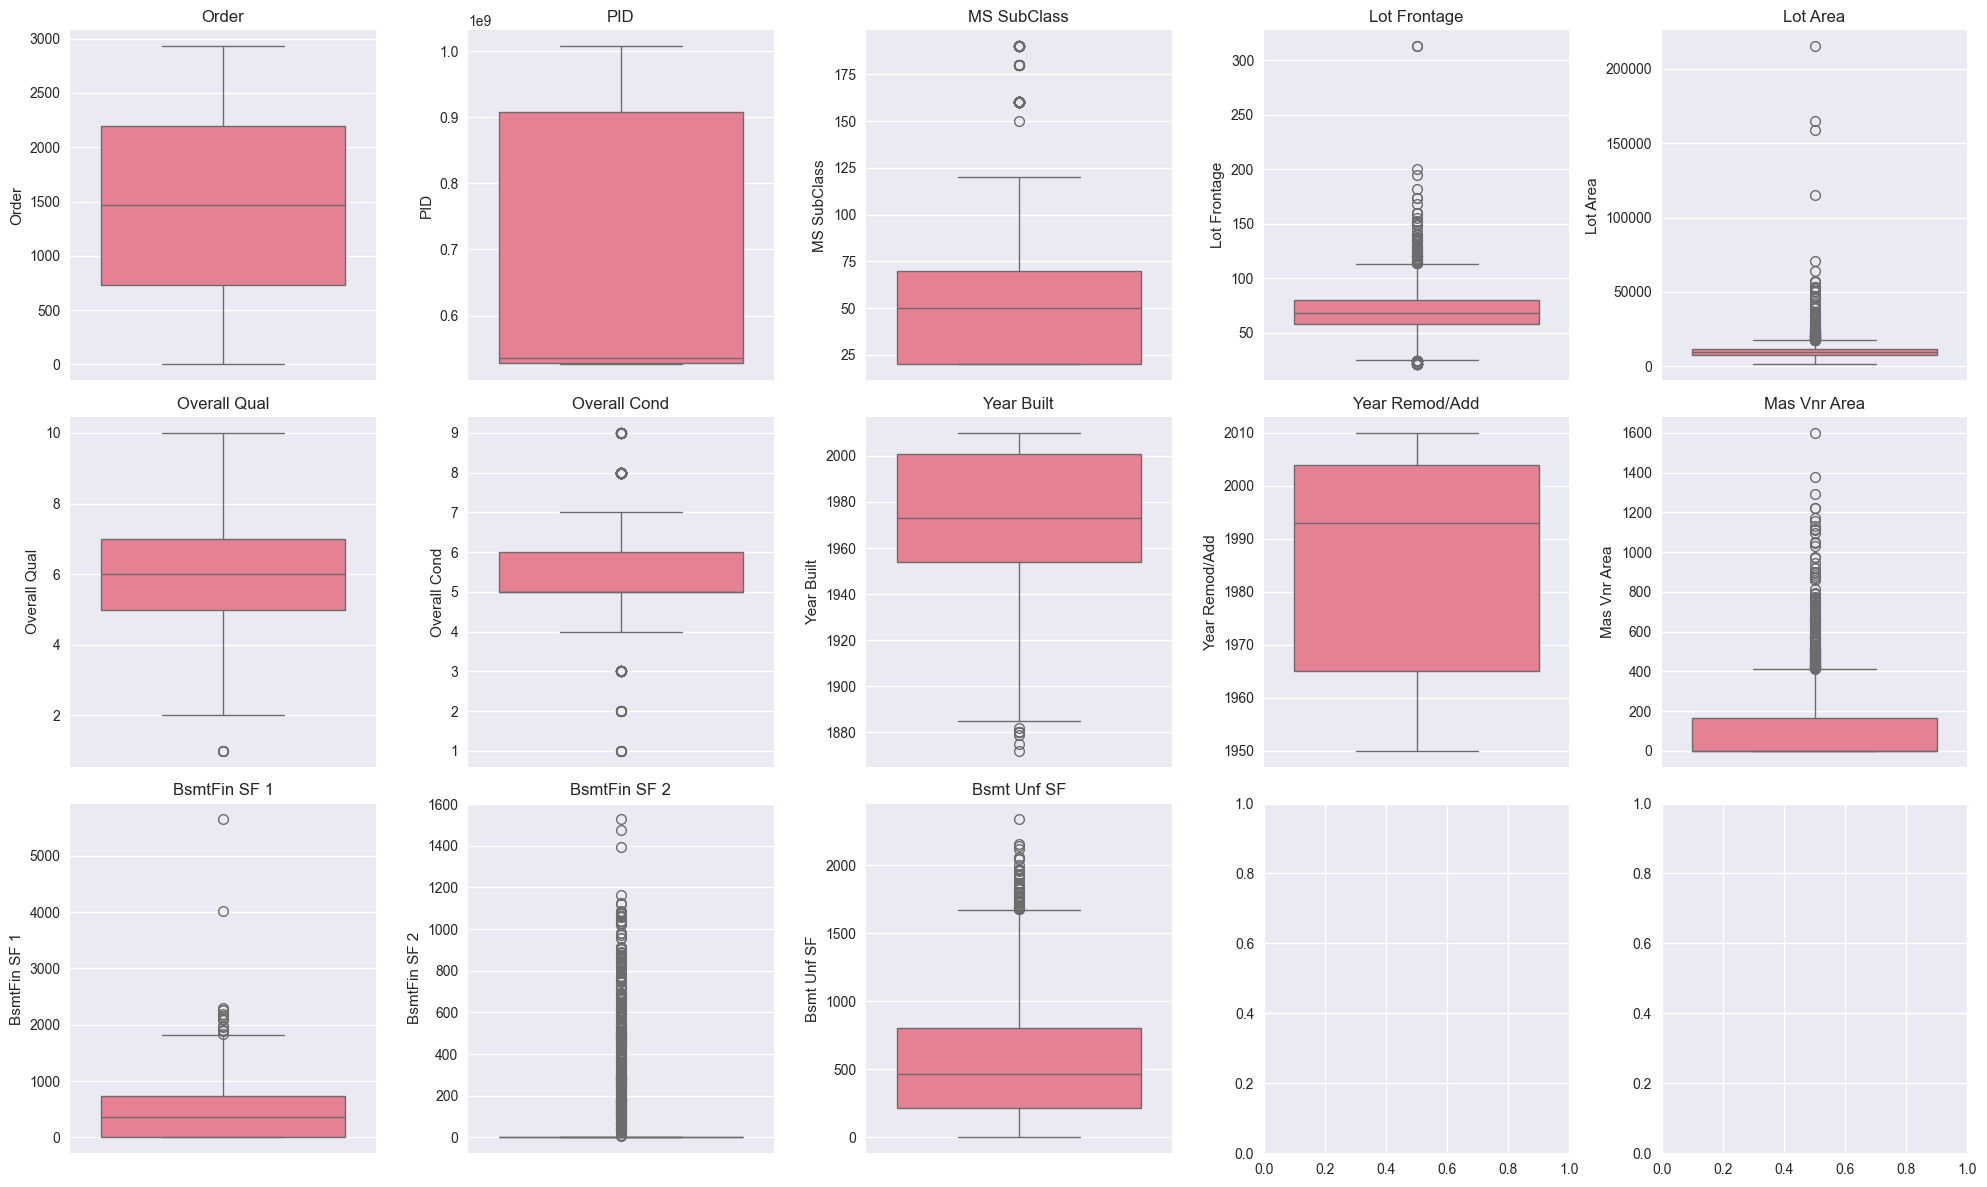

In [17]:
# Boxplort de las columnas seleccionadas
plt.subplots(3, 5,figsize=(20, 12))

for i, col in enumerate(selected_features):
    plt.subplot(3, 5, i+1)
    sns.boxplot(y=df_selected[col])
    plt.title(col)
    plt.tight_layout()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    df_raw[selected_features],
    df_raw['SalePrice'],
    test_size=0.2,
    random_state=42
)

In [33]:
# === TU EXPERIMENTO: OUTLIERS Y ESCALADO ===

# TODO: Implementa funciones de detección de outliers (práctica 05)
# IQR method, Z-score method, u otros que prefieras
def detect_outliers_iqr(data, column_name, factor=1.5):
    """Outliers por IQR. Devuelve (df_outliers, lower, upper)."""
    x = pd.to_numeric(data[column_name], errors="coerce")
    x_no_na = x.dropna().astype(float).values
    if x_no_na.size == 0:
        # sin datos válidos
        return data.iloc[[]], np.nan, np.nan
    q1 = np.percentile(x_no_na, 25)
    q3 = np.percentile(x_no_na, 75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    mask = (pd.to_numeric(data[column_name], errors="coerce") < lower) | (pd.to_numeric(data[column_name], errors="coerce") > upper)
    return data[mask], lower, upper

def detect_outliers_zscore(data, column_name, threshold=3):
    """Detectar outliers usando Z-Score - Regla: 3 desvios desde el promedio = raro"""
    from scipy import stats
    z_scores = np.abs(stats.zscore(data[column_name].dropna()))
    outlier_indices = data[column_name].dropna().index[z_scores > threshold]
    return data.loc[outlier_indices]

# TODO: Elige una columna interesante para analizar
target_column = 'Mas Vnr Area'

# TODO: ROUND 1 - Detección en datos originales
print("🔍 ROUND 1: DATOS ORIGINALES")
# Detecta outliers en datos sin escalar
# ¿Cuántos outliers encontraste? ¿Dónde están?

original_outliers = detect_outliers_zscore(df_raw, target_column)
print(f"Outliers detectados en '{target_column}': {len(original_outliers)}")
original_outliers_iqr = detect_outliers_iqr(df_raw, target_column)[0]
print(f"Outliers detectados por IQR en '{target_column}': {len(original_outliers_iqr)}")

# TODO: ROUND 2 - Detección después de cada scaler
scalers_to_test = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

print("⚡ ROUND 2: DESPUÉS DEL ESCALADO")
# Para cada scaler:
# 1. Aplica el scaler a tus datos
# 2. Detecta outliers en los datos escalados
# 3. Compara con los outliers originales
for scaler_name, scaler in scalers_to_test.items():
    print(f"\n--- Usando {scaler_name} ---")
    # Aplica el scaler
    df_raw_copy = df_raw[selected_features].copy()
    scaler.fit(X_train)
    df_raw_copy[selected_features] = scaler.transform(df_raw_copy[selected_features])
     # Detecta outliers en los datos escalados
    scaled_outliers = detect_outliers_zscore(df_raw_copy, target_column)
    print(f"Outliers detectados en '{target_column}' después de {scaler_name}: {len(scaled_outliers)}")
    scaled_outliers_iqr = detect_outliers_iqr(df_raw_copy, target_column)[0]
    print(f"Outliers detectados por IQR en '{target_column}' después de {scaler_name}: {len(scaled_outliers_iqr)}")

# TODO: Análisis de resultados
# ¿Qué scaler detectó más/menos outliers?
# ¿Los mismos puntos siguen siendo outliers?
# ¿RobustScaler cambió la detección como esperabas?

🔍 ROUND 1: DATOS ORIGINALES
Outliers detectados en 'Mas Vnr Area': 63
Outliers detectados por IQR en 'Mas Vnr Area': 200
⚡ ROUND 2: DESPUÉS DEL ESCALADO

--- Usando StandardScaler ---
Outliers detectados en 'Mas Vnr Area' después de StandardScaler: 63
Outliers detectados por IQR en 'Mas Vnr Area' después de StandardScaler: 200

--- Usando MinMaxScaler ---
Outliers detectados en 'Mas Vnr Area' después de MinMaxScaler: 63
Outliers detectados por IQR en 'Mas Vnr Area' después de MinMaxScaler: 200

--- Usando RobustScaler ---
Outliers detectados en 'Mas Vnr Area' después de RobustScaler: 63
Outliers detectados por IQR en 'Mas Vnr Area' después de RobustScaler: 200
